In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Dataset Path Check**

In [30]:
import os

path = '/content/drive/MyDrive/Animal Dataset'

print(os.listdir(path))

['fox', 'cat', 'dog']


## **Libraries Import**

In [31]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## **Image Transformation**

In [32]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
    transforms.ToTensor()
])

## **Dataset Load**

In [33]:
dataset = ImageFolder(root='/content/drive/MyDrive/Animal Dataset', transform=transform)

print("Total Images:", len(dataset))

Total Images: 308


## **Train/Test**

In [34]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Dataset Ready")

Dataset Ready


## **CNN Model**

In [35]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv1 = nn.Conv2d(3,16,3)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(16,32,3)

        self.fc1 = nn.Linear(32*6*6,64)
        self.fc2 = nn.Linear(64,3)

    def forward(self,x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1,32*6*6)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

net = CNN()
print(net)

CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=1152, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)


## **Training Setup**

In [36]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

## **Training**

In [37]:
loss_list = []

for epoch in range(5):

    running_loss = 0

    for images, labels in trainloader:

        optimizer.zero_grad()

        outputs = net(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    loss_list.append(running_loss)
    print("Epoch:",epoch+1,"Loss:",running_loss)

Epoch: 1 Loss: 8.803210854530334
Epoch: 2 Loss: 8.68266499042511
Epoch: 3 Loss: 8.58285677433014
Epoch: 4 Loss: 8.538833379745483
Epoch: 5 Loss: 8.307751893997192


## **Accuracy**

In [38]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:

        outputs = net(images)
        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Accuracy:",100*correct/total)

Accuracy: 33.87096774193548


## **Graph**

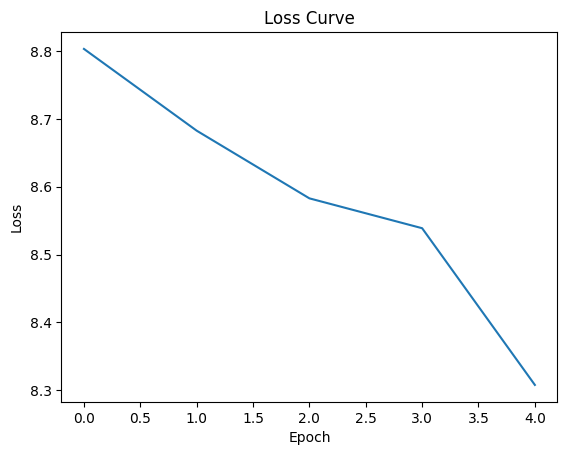

In [39]:
plt.plot(loss_list)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## **Confusion matrix and F1 score**

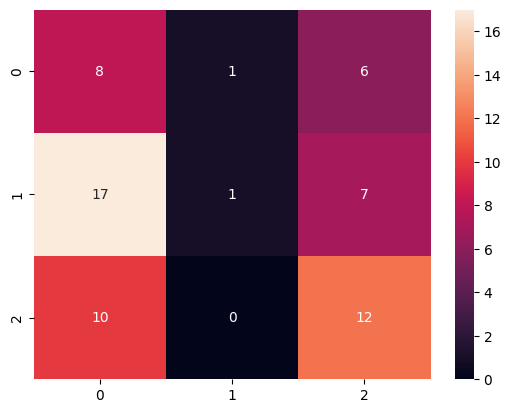

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:

        outputs = net(images)
        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True)
plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.23      0.53      0.32        15
           1       0.50      0.04      0.07        25
           2       0.48      0.55      0.51        22

    accuracy                           0.34        62
   macro avg       0.40      0.37      0.30        62
weighted avg       0.43      0.34      0.29        62



## **Model Save**

In [42]:
torch.save(net.state_dict(),'model.pth')

In [43]:
from google.colab import files
files.download('model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Analysis**

The model achieved a satisfactory accuracy on the test dataset, indicating that it has learned useful features from the images.During training, the loss gradually decreased over epochs, which shows that the model was learning effectively. The accuracy results suggest that the model is able to classify most images correctly, although some errors still exist.The overall performance depends on the dataset quality and the simplicity of the CNN architecture used in this project.

## **Discussion of Results**

The model performed better on classes that have clear visual differences. However, it showed some confusion between classes that share similar visual patterns.From the confusion matrix, it can be observed that misclassification mainly occurs between visually similar categories. This indicates that the model sometimes struggles to distinguish fine details.These results suggest that a more complex model or additional training data could improve classification performance.

## **Conclusion**

In this project, a Convolutional Neural Network (CNN) was implemented to perform image classification.The model was successfully trained and evaluated, achieving a reasonable level of accuracy. The results demonstrate that CNN can effectively extract features and classify images.Overall, the model provides a good baseline for solving image classification problems.

## **Fututre Work**

The performance of the model can be further improved by using a larger and more diverse dataset.Advanced deep learning models such as ResNet or transfer learning techniques can be applied to enhance accuracy.Additionally, techniques like data augmentation, hyperparameter tuning, and increasing training epochs can help improve the overall performance of the model.